# Load Built-in Dataset

In [2]:
from surprise import Dataset, Reader

# Path to the u.data file
file_path = r"C:\Users\pouya\Downloads\Recommender_system-master\Recommender_system-master\dataset\dataset\ml-100k\u.data"

# Define the format (user, item, rating, timestamp)
reader = Reader(line_format='user item rating timestamp', sep='\t')

# Load the dataset
data = Dataset.load_from_file(file_path, reader=reader)

type(data)

surprise.dataset.DatasetAutoFolds

# Data Splitting & Exploration

In [3]:
from surprise.model_selection import train_test_split

# 80% train, 20% test
trainset, testset = train_test_split(data=data,
                                         test_size=0.2,
                                         random_state=43)

# Here trainset is a Trainset object but testset is a list
print(f"Train data: {trainset.n_ratings}")
print(f"Test data: {len(testset)}")
print(f"Train users: {trainset.n_users}")
print(f"Train items: {trainset.n_items}")

Train data: 80000
Test data: 20000
Train users: 943
Train items: 1645


## Model Training: SVD (Singular Value Decomposition)

In [4]:
from surprise import SVD

# Initialize SVD model
svd_model = SVD(n_factors=100,  # latent factros (number of hidden features)
                n_epochs=20,    # Training iterations
                lr_all=0.005,   # Learning rate
                reg_all=0.02)   # Regularization

# Train on 80% of data
svd_model.fit(trainset)

## Making Predictions with the Trained SVD Model


In [5]:
svd_model.predict(uid="10", iid="196"), svd_model.predict(uid="25", iid="365")

(Prediction(uid='10', iid='196', r_ui=None, est=4.137305421482625, details={'was_impossible': False}),
 Prediction(uid='25', iid='365', r_ui=None, est=3.1908625146845244, details={'was_impossible': False}))

## Hyperparameter Tuning with GridSearchCV


In [ ]:
from surprise.model_selection import GridSearchCV

# Define hyperparameter grid to search
svd_param_grid = {
    "n_factors": [50, 100, 150],
    "n_epochs": [20, 30],
    "lr_all": [0.005, 0.01, 0.001],
    "reg_all":[0.02, 0.1]
}

# 3-fold cross-validation to find the best parameters
svd_gs = GridSearchCV(algo_class=SVD,
                  param_grid=svd_param_grid,
                  measures=["rmse", "mae"], 
                  cv=3)

# Run search on all data
svd_gs.fit(data)

Best RMSE score: 0.9213724992700437
Best RMSE score: 0.728746348040565
Best Parameters: {'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1}


## Training Final Model with The Best Parameters

In [34]:
# Unpack best parameters and initialize SVD
best_svd_model = SVD(**svd_gs.best_params["rmse"])
best_svd_model.fit(trainset)

## Model Evaluation


In [35]:
from surprise import accuracy

# Generate predictions on test set (unseen data)
svd_predictions = svd_model.test(testset)

# Calculate evaluations metrics
svd_rmse = accuracy.rmse(svd_predictions)
svd_mae = accuracy.mae(svd_predictions)

print(svd_rmse, svd_mae)

RMSE: 0.9404
MAE:  0.7415
0.9404343821669481 0.7415307215349594


## Making Predictions with the Trained Model

In [ ]:
best_svd_model.predict(uid="10", iid="196"), best_svd_model.predict(uid="25", iid="365")

(Prediction(uid='10', iid='196', r_ui=None, est=4.168601333292553, details={'was_impossible': False}),
 Prediction(uid='25', iid='365', r_ui=None, est=3.5055409283553414, details={'was_impossible': False}))

## Finding High-Rated Predictions (Users & Items 1-100)

In [ ]:
high_ratings = []

# First 100 users and items
users = range(1, 101)
items = range(1, 101)

# Loop through all users-items combinations and keep only >=4.7 stars
for user in users:
    for item in items:
        pred = best_svd_model.predict(str(user), str(item))
        if pred.est >= 4.7:
            high_ratings.append((user, item, pred.est))

print(f"Found {len(high_ratings)} predictions above 4.7! \n")

for user, item, est in high_ratings:
    print(f"User {user} → Item {item}: {est:.2f}")

# shows the unique users and items
print(f"\nUnique users: {len(set([user for user, item, rate in high_ratings]))}")
print(f"Unique items: {len(set([item for user, item, rate in high_ratings]))}")

Found 96 predictions above 4.7! 

User 4 → Item 8: 4.76
User 4 → Item 9: 4.90
User 4 → Item 10: 4.91
User 4 → Item 12: 5.00
User 4 → Item 14: 4.87
User 4 → Item 19: 5.00
User 4 → Item 22: 4.72
User 4 → Item 23: 4.84
User 4 → Item 30: 5.00
User 4 → Item 45: 4.92
User 4 → Item 48: 4.98
User 4 → Item 50: 4.86
User 4 → Item 52: 4.71
User 4 → Item 56: 4.94
User 4 → Item 57: 5.00
User 4 → Item 59: 5.00
User 4 → Item 60: 5.00
User 4 → Item 61: 4.91
User 4 → Item 64: 5.00
User 4 → Item 83: 4.86
User 4 → Item 86: 4.86
User 4 → Item 87: 4.88
User 4 → Item 89: 5.00
User 4 → Item 91: 4.76
User 4 → Item 96: 4.73
User 4 → Item 98: 5.00
User 4 → Item 100: 4.95
User 7 → Item 12: 4.74
User 7 → Item 50: 4.71
User 7 → Item 64: 4.81
User 8 → Item 50: 4.71
User 9 → Item 12: 4.72
User 9 → Item 64: 4.79
User 10 → Item 64: 4.74
User 12 → Item 22: 4.82
User 12 → Item 64: 5.00
User 12 → Item 98: 4.73
User 16 → Item 12: 4.94
User 16 → Item 22: 4.73
User 16 → Item 50: 4.95
User 16 → Item 64: 4.95
User 16 → Item 7

## Evaluating Model on Test Set


In [ ]:
print("First 10 testset ratings (user, item, rating):\n")

for i, (user, item, rating) in enumerate(testset[:10]):
    pred = round(best_svd_model.predict(str(user), str(item)).est, 2)
    print(f"User {user} → Item {item}: Real: {rating} → Predicted:{pred}")

First 10 testset ratings (user, item, rating):

User 160 → Item 150: Real: 4.0 → Predicted:4.21
User 95 → Item 65: Real: 4.0 → Predicted:3.43
User 347 → Item 97: Real: 4.0 → Predicted:3.81
User 927 → Item 763: Real: 4.0 → Predicted:3.33
User 747 → Item 403: Real: 5.0 → Predicted:3.78
User 265 → Item 591: Real: 5.0 → Predicted:3.76
User 883 → Item 277: Real: 4.0 → Predicted:3.73
User 682 → Item 298: Real: 4.0 → Predicted:3.65
User 233 → Item 521: Real: 5.0 → Predicted:4.09
User 456 → Item 743: Real: 2.0 → Predicted:2.4


## Training Final Model with The Best Parameters

In [ ]:
# Unpack best parameters and initialize SVD
best_svd_model = SVD(**svd_gs.best_params["rmse"])
best_svd_model.fit(trainset)

## Making Predictions with the Trained Model

In [9]:
best_svd_model.predict(uid="10", iid="196"), best_svd_model.predict(uid="25", iid="365")

(Prediction(uid='10', iid='196', r_ui=None, est=4.168601333292553, details={'was_impossible': False}),
 Prediction(uid='25', iid='365', r_ui=None, est=3.5055409283553414, details={'was_impossible': False}))

## Finding High-Rated Predictions (Users & Items 1-100)

In [10]:
high_ratings = []

# First 100 users and items
users = range(1, 101)
items = range(1, 101)

# Loop through all users-items combinations and keep only >=4.7 stars
for user in users:
    for item in items:
        pred = best_svd_model.predict(str(user), str(item))
        if pred.est >= 4.7:
            high_ratings.append((user, item, pred.est))

print(f"Found {len(high_ratings)} predictions above 4.7! \n")

for user, item, est in high_ratings:
    print(f"User {user} → Item {item}: {est:.2f}")

# shows the unique users and items
print(f"\nUnique users: {len(set([user for user, item, rate in high_ratings]))}")
print(f"Unique items: {len(set([item for user, item, rate in high_ratings]))}")

Found 96 predictions above 4.7! 

User 4 → Item 8: 4.76
User 4 → Item 9: 4.90
User 4 → Item 10: 4.91
User 4 → Item 12: 5.00
User 4 → Item 14: 4.87
User 4 → Item 19: 5.00
User 4 → Item 22: 4.72
User 4 → Item 23: 4.84
User 4 → Item 30: 5.00
User 4 → Item 45: 4.92
User 4 → Item 48: 4.98
User 4 → Item 50: 4.86
User 4 → Item 52: 4.71
User 4 → Item 56: 4.94
User 4 → Item 57: 5.00
User 4 → Item 59: 5.00
User 4 → Item 60: 5.00
User 4 → Item 61: 4.91
User 4 → Item 64: 5.00
User 4 → Item 83: 4.86
User 4 → Item 86: 4.86
User 4 → Item 87: 4.88
User 4 → Item 89: 5.00
User 4 → Item 91: 4.76
User 4 → Item 96: 4.73
User 4 → Item 98: 5.00
User 4 → Item 100: 4.95
User 7 → Item 12: 4.74
User 7 → Item 50: 4.71
User 7 → Item 64: 4.81
User 8 → Item 50: 4.71
User 9 → Item 12: 4.72
User 9 → Item 64: 4.79
User 10 → Item 64: 4.74
User 12 → Item 22: 4.82
User 12 → Item 64: 5.00
User 12 → Item 98: 4.73
User 16 → Item 12: 4.94
User 16 → Item 22: 4.73
User 16 → Item 50: 4.95
User 16 → Item 64: 4.95
User 16 → Item 7

## Evaluating Model on Test Set


In [11]:
print("First 10 testset ratings (user, item, rating):\n")

for i, (user, item, rating) in enumerate(testset[:10]):
    pred = round(best_svd_model.predict(str(user), str(item)).est, 2)
    print(f"User {user} → Item {item}: Real: {rating} → Predicted:{pred}")

First 10 testset ratings (user, item, rating):

User 160 → Item 150: Real: 4.0 → Predicted:4.21
User 95 → Item 65: Real: 4.0 → Predicted:3.43
User 347 → Item 97: Real: 4.0 → Predicted:3.81
User 927 → Item 763: Real: 4.0 → Predicted:3.33
User 747 → Item 403: Real: 5.0 → Predicted:3.78
User 265 → Item 591: Real: 5.0 → Predicted:3.76
User 883 → Item 277: Real: 4.0 → Predicted:3.73
User 682 → Item 298: Real: 4.0 → Predicted:3.65
User 233 → Item 521: Real: 5.0 → Predicted:4.09
User 456 → Item 743: Real: 2.0 → Predicted:2.4


## KNNBaseline Model Tuning with GridSearchCV


In [12]:
from surprise import KNNBaseline
from surprise.model_selection import GridSearchCV

knn_param_grid = {
    'k': [20, 40, 60, 80],
    'min_k': [1, 3, 5],
    'sim_options': {
        'name': ['cosine', 'msd', 'pearson'],
        'user_based': [True, False]  # True = user-user, False = item-item
    }
}

knn_gs = GridSearchCV(algo_class=KNNBaseline,
                      param_grid=knn_param_grid,
                      measures=['rmse', 'mae'], 
                      cv=3)

knn_gs.fit(data=data)

Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Comput

## Get Best Params & Create New Model With Best Params


In [ ]:
best_knn_params = knn_gs.best_params['rmse']
best_knn_model = KNNBaseline(**best_knn_params)

## Training the Best KNNBaseline Model


In [26]:
best_knn_model.fit(trainset)

Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.


## Evaluating KNN Baseline Model on Test Set

In [27]:
from surprise import accuracy

knn_predictions = best_knn_model.test(testset)
knn_rmse = accuracy.rmse(knn_predictions)
knn_mae = accuracy.mae(knn_predictions)

RMSE: 0.9352
MAE:  0.7375


## Baseline Only Model Tuning with GridSearchCV


In [28]:
from surprise import BaselineOnly
from surprise.model_selection import GridSearchCV

baseline_param_grid = {
        'bsl_options': {
        'method': ['sgd', 'als'],  
        'n_epochs': [20, 30],      
        'reg': [0.02, 0.1]         
    }
}

baseline_gs = GridSearchCV(algo_class=BaselineOnly,
                           param_grid=baseline_param_grid,
                           measures=['rmse','mae'],
                           cv=3,
                           refit=True)

baseline_gs.fit(data=data)

Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using sgd...


## Get Best Params & Create New Model With Best Params

In [29]:
best_baseline_params = baseline_gs.best_params['rmse']
best_baseline_model = KNNBaseline(**best_baseline_params)

## Training the Best BaselineOnly Model


In [30]:
best_baseline_model.fit(trainset)

Estimating biases using sgd...
Computing the msd similarity matrix...
Done computing similarity matrix.


## Evaluating KNN Baseline Model on Test Set

In [31]:
from surprise import accuracy

baseline_predictions = best_baseline_model.test(testset)
baseline_rmse = accuracy.rmse(baseline_predictions)
baseline_mae = accuracy.mae(baseline_predictions)

RMSE: 0.9383
MAE:  0.7397


## SlopeOne Model - Cross-Validation


In [53]:
from surprise import SlopeOne
from surprise.model_selection import cross_validate
from surprise import accuracy

slopeone_model = SlopeOne()

slopeone_results = cross_validate(algo=slopeone_model,
                                  data=data,
                                  measures=["rmse", "mae"],
                                  cv=5,
                                  verbose=True)

slopeone_rmse = slopeone_results['test_rmse'].mean()
slopeone_mae = slopeone_results['test_mae'].mean()

Evaluating RMSE, MAE of algorithm SlopeOne on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9385  0.9456  0.9402  0.9422  0.9572  0.9447  0.0067  
MAE (testset)     0.7387  0.7422  0.7403  0.7406  0.7523  0.7428  0.0049  
Fit time          0.61    0.62    0.63    0.62    0.64    0.63    0.01    
Test time         1.53    1.51    1.51    1.64    1.53    1.54    0.05    


## Evaluating SlopeOne

In [56]:
print(f"RMSE: {slopeone_rmse:.4f}")
print(f"MAE:  {slopeone_mae:.4f}")

RMSE: 0.9447
MAE:  0.7428


In [65]:
svd_rmse, knn_rmse, baseline_rmse, slopeone_rmse

(0.9404343821669481,
 0.9352187032905152,
 0.9383104453243076,
 0.9447271423304885)

## RMSE Comparison Bar Chart

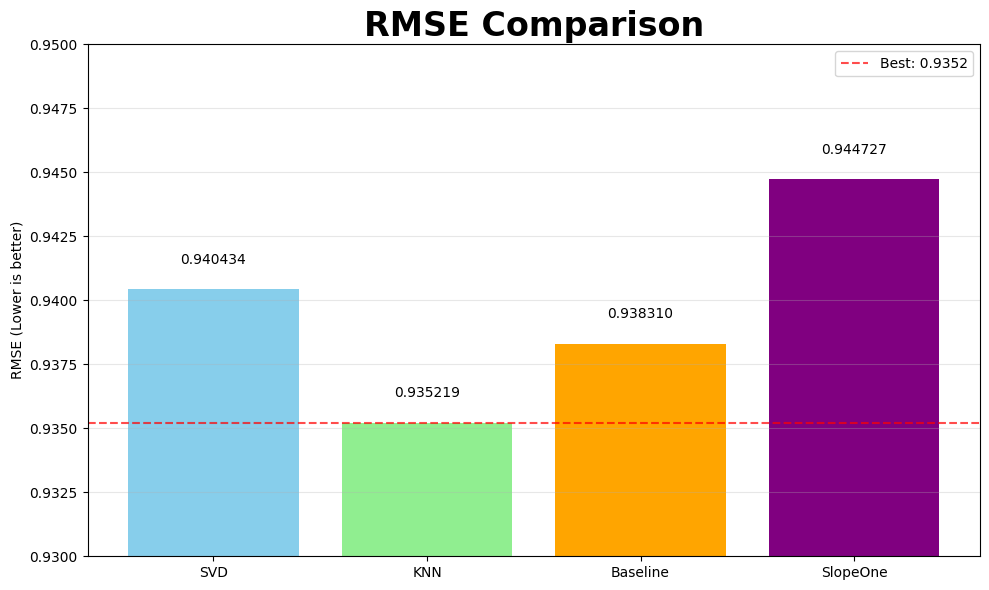

In [109]:
import matplotlib.pyplot as plt

models = ['SVD', 'KNN', 'Baseline', 'SlopeOne']
rmse_values = [svd_rmse, knn_rmse, baseline_rmse, slopeone_rmse]

plt.figure(figsize=(10, 6))

plt.bar(x=models,
        height=rmse_values,
        color=['skyblue', 'lightgreen', 'orange', 'purple'])

plt.ylabel("RMSE (Lower is better)")

plt.title("RMSE Comparison", 
          fontsize=24, 
          fontweight='bold')

# Zoom y-axis 
plt.ylim(0.93, 0.95)

# add light horizontal grid lines
plt.grid(axis='y', alpha=0.3)

# Find the best (lowest) RMSE value
min_rmse = min(rmse_values)

# Draw horizontal dashed line at the best RMSE value
plt.axhline(y=min_rmse,
            color='red',
            linestyle="--",
            alpha=0.7,
            label = f"Best: {min_rmse:.4f}")

# Add RMSE value labels on top of each bar
for index, value in enumerate(rmse_values):
    # Adds text at position(x, y)
    plt.text(x= index,               # X-coordinate
             y = value + 0.001,      # y-coordinate + slight value to place it above the bar
             s = f'{value:4f}',      # string
             ha='center')            # horizontal alignment

plt.legend()

plt.tight_layout()
plt.show()
